In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Farm 2019 Expenses vs. Income july to december.xlsx
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Farm Expenses Jan- June 2021.xlsx
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Desi Farm Report July to Dec 2023.xlsx
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Farm Expenses July-Dec 2020.xlsx
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Desi Farm Report July-Dec 2024.xlsx
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/livestock sale purchase record.xlsx
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Desi Farm Report Jan-Jun 2023.xlsx
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Desi_Farm_Master_Data.csv
/kaggle/input/datasets/imran495/dairy

# 🐄 Desi Farm: Business Case Study & Exploratory Data Analysis

## 1. Introduction & Business Context

### The Situation
Desi Farm (SMC-Private) Limited has been actively operating and maintaining daily financial ledgers over a 7-year period (2019–2025). The farm's management has meticulously recorded every transaction, ranging from daily operational expenses (feed, fodder, veterinary care, and maintenance) to capital asset management (buying and selling of livestock). 

### The Concern (Why are we doing this study?)
While the raw financial ledgers accurately track *what* money was spent and earned, they do not automatically explain *how efficiently* the farm is operating. In the dairy and agricultural sector, profit margins are highly sensitive to seasonal changes, inflation in feed costs, and the lifecycle of the livestock. 
Relying solely on a raw ledger makes it difficult to answer critical business questions:
* Are the daily operational costs (like feed and electricity) eating into the milk revenue?
* Is the farm actually profitable on a month-to-month basis, or are capital asset sales (selling animals) masking operational losses?
* Which expenses are the biggest financial drains, and how do they fluctuate throughout the year?

### The Objective
The goal of this Exploratory Data Analysis (EDA) is to transform 7 years of unstructured ledger entries into actionable business intelligence. By separating day-to-day operational cash flows from livestock capital gains, we aim to uncover the true net profitability of Desi Farm. The insights derived from this study will help identify cost-saving opportunities, optimize feed inventory, and provide a clear financial roadmap for future agricultural investments.

In [2]:
import pandas as pd

# 1. Load data using exact file paths
expenses_path = '/kaggle/input/notebooks/imran495/data-cleaning-etl-desi-dairy-farm/Desi_Farm_Expenses.csv'
income_path = '/kaggle/input/notebooks/imran495/data-cleaning-etl-desi-dairy-farm/Desi_Farm_Income.csv'

df_expenses = pd.read_csv(expenses_path)
df_income = pd.read_csv(income_path)

# 2. Clean and standardize data types (Dates and Numbers)
df_expenses['date'] = pd.to_datetime(df_expenses['date'], errors='coerce')
df_income['date'] = pd.to_datetime(df_income['date'], errors='coerce')

df_expenses['amount'] = pd.to_numeric(df_expenses['amount'], errors='coerce').fillna(0)
df_income['amount'] = pd.to_numeric(df_income['amount'], errors='coerce').fillna(0)

# 3. Create a 'month_year' column to group data by month
df_expenses['month_year'] = df_expenses['date'].dt.to_period('M')
df_income['month_year'] = df_income['date'].dt.to_period('M')

# 4. Aggregate monthly totals for both Income and Expenses
monthly_expenses = df_expenses.groupby('month_year')['amount'].sum().reset_index(name='total_expense')
monthly_income = df_income.groupby('month_year')['amount'].sum().reset_index(name='total_income')

# 5. Merge into a final monthly summary table and calculate Net Profit
monthly_finance = pd.merge(monthly_income, monthly_expenses, on='month_year', how='outer').fillna(0)
monthly_finance['net_profit'] = monthly_finance['total_income'] - monthly_finance['total_expense']

# 6. Sort chronologically from July 2019 to October 2025
monthly_finance = monthly_finance.sort_values('month_year').reset_index(drop=True)

print("✅ Monthly Financial Data Successfully Prepared!")
display(monthly_finance.head(20))


✅ Monthly Financial Data Successfully Prepared!


,month_year,total_income,total_expense,net_profit
0,2019-06,0.0,39000.0,-39000.0
1,2019-07,0.0,32750.0,-32750.0
2,2019-08,0.0,61800.0,-61800.0
3,2019-09,0.0,36800.0,-36800.0
4,2019-10,0.0,64080.0,-64080.0
5,2019-11,0.0,127410.0,-127410.0
6,2019-12,444000.0,542411.0,-98411.0
7,2020-01,126690.0,190968.0,-64278.0
8,2020-02,117430.0,129801.0,-12371.0
9,2020-03,133470.0,220388.0,-86918.0


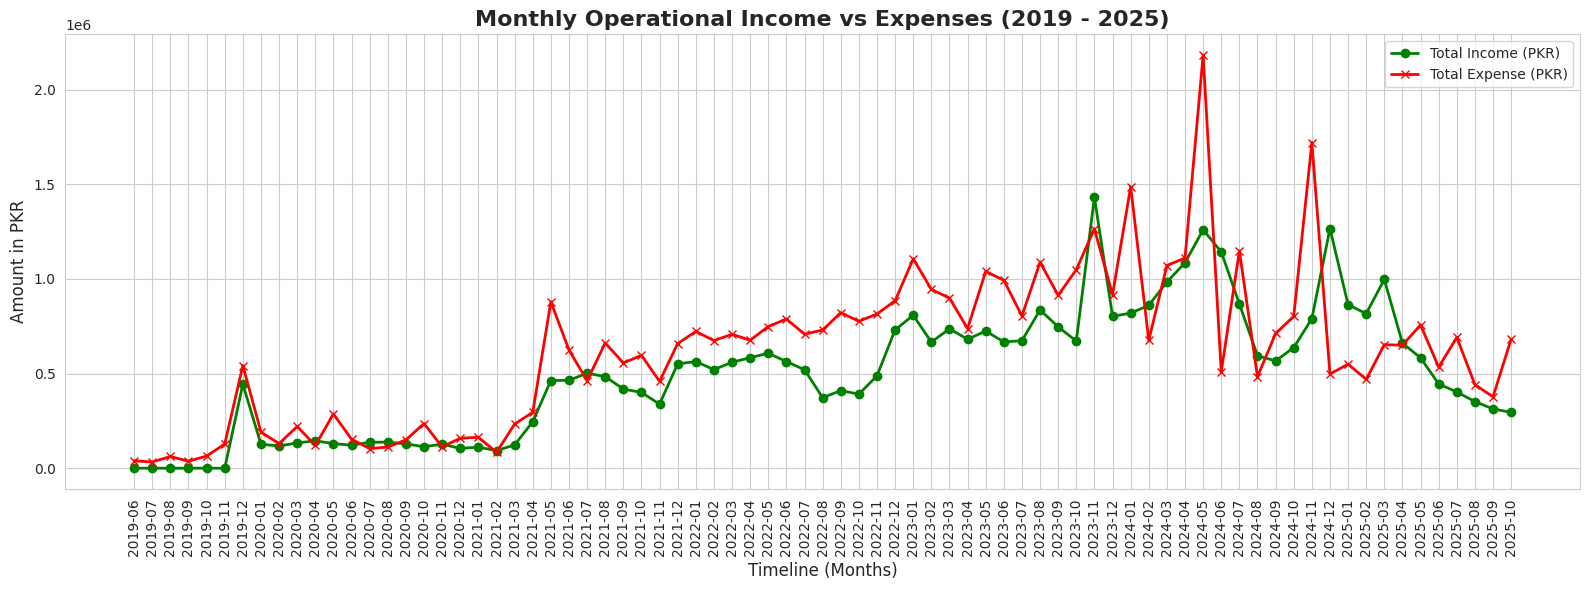

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'month_year' to string format so it plots correctly on the X-axis
monthly_finance['month_str'] = monthly_finance['month_year'].astype(str)

# Set the style and size of the graph
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

# Plot Total Income vs Total Expense over time
plt.plot(monthly_finance['month_str'], monthly_finance['total_income'], label='Total Income (PKR)', color='green', marker='o', linewidth=2)
plt.plot(monthly_finance['month_str'], monthly_finance['total_expense'], label='Total Expense (PKR)', color='red', marker='x', linewidth=2)

# Customize the chart labels and title
plt.title('Monthly Operational Income vs Expenses (2019 - 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Months)', fontsize=12)
plt.ylabel('Amount in PKR', fontsize=12)
plt.xticks(rotation=90) # Rotate month labels so they are easy to read
plt.legend()
plt.tight_layout()

# Show the clean financial graph
plt.show()


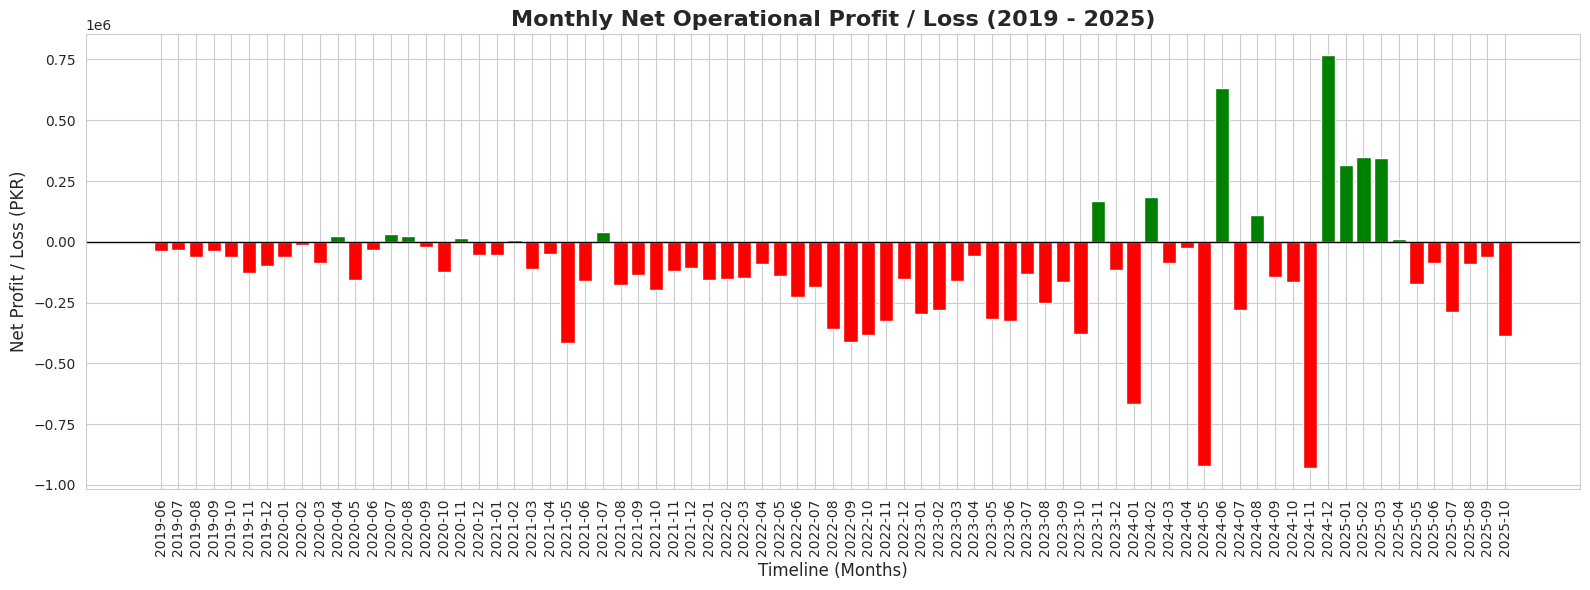

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Set the figure size for the dashboard
plt.figure(figsize=(16, 6))

# Define conditional colors: Green for profit (>= 0), Red for loss (< 0)
colors = ['green' if val >= 0 else 'red' for val in monthly_finance['net_profit']]

# Create a bar chart to visualize Net Profit and Loss
plt.bar(monthly_finance['month_str'], monthly_finance['net_profit'], color=colors)

# Add professional title and axis labels
plt.title('Monthly Net Operational Profit / Loss (2019 - 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Months)', fontsize=12)
plt.ylabel('Net Profit / Loss (PKR)', fontsize=12)

# Rotate x-axis month labels for better readability
plt.xticks(rotation=90) 

# Add a distinct horizontal baseline at zero to separate profit from loss
plt.axhline(0, color='black', linewidth=1) 

# Adjust layout to prevent label clipping
plt.tight_layout()

# Display the generated chart
plt.show()


## 3. Financial Deep Dive: Averages and Expense Categorization

### The Cash Flow Illusion (Bulk Purchasing)
Observing the Net Profit/Loss chart, we can identify a distinct pattern: periods of massive negative cash flows (huge expenses) followed immediately by several months of consistent "profits." In the context of dairy farming, this heavily indicates **bulk inventory purchasing**. Feed and fodder (such as silage and wheat straw) are typically purchased in massive quantities during the harvest season. While this heavily skews the cash flow negatively for that specific month, it lowers daily operational costs for the subsequent months, creating a pattern of sustained apparent profitability.

### Objective
To validate this business model behavior, we will now:
1. Calculate the **Average Monthly Net Profit/Loss** to see the true baseline of the farm.
2. Analyze the **Expense Categories** to prove that Diet (Feed + Fodder) represents the overwhelming majority of the capital drain.

📊 Average Monthly Net Profit/Loss: -117,452.38 PKR
--------------------------------------------------
Top Expense Categories (in PKR):


,category,amount
5,Fodder,19282474.5
3,Feed,12651666.0
11,Salaries,5285236.0
2,Electricity Bills,3186689.0
9,Miscellaneous,3119984.0


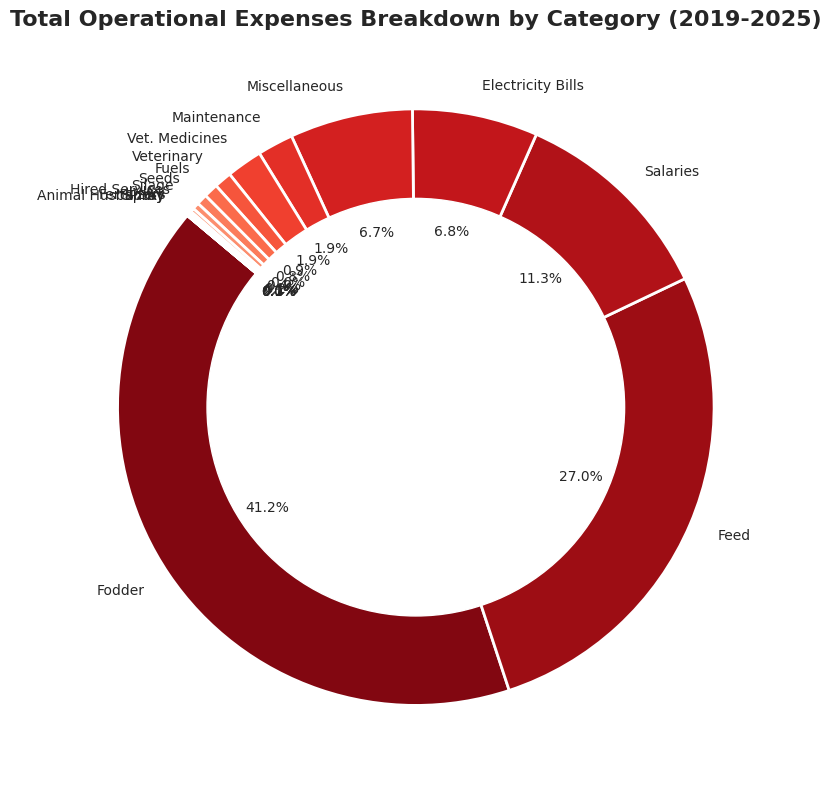

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Average Monthly Net Profit / Loss
average_monthly_profit = monthly_finance['net_profit'].mean()
print(f"📊 Average Monthly Net Profit/Loss: {average_monthly_profit:,.2f} PKR")
print("-" * 50)

# 2. Group expenses by their exact categories
category_expenses = df_expenses.groupby('category')['amount'].sum().reset_index()
category_expenses = category_expenses.sort_values(by='amount', ascending=False)

# Print the exact numbers for the top categories
print("Top Expense Categories (in PKR):")
display(category_expenses.head())

# 3. Data Visualization: Expense Breakdown Pie Chart
plt.figure(figsize=(10, 8))

# Using a red color palette to represent expenses
colors = sns.color_palette("Reds_r", len(category_expenses))

# Create a donut-style pie chart for a modern dashboard look
plt.pie(category_expenses['amount'], labels=category_expenses['category'], 
        autopct='%1.1f%%', startangle=140, colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# Draw a white circle in the center to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Total Operational Expenses Breakdown by Category (2019-2025)', fontsize=16, fontweight='bold')
plt.tight_layout()

# Show the chart
plt.show()

## 4. The True Cost of Dairy Farming: Diet vs. Everything Else

### Merging Feed and Fodder
In the dairy sector, 'Feed' (concentrates/wanda) and 'Fodder' (silage/green grass) are functionally the same expense: **Animal Nutrition (Diet)**. By treating them separately, we dilute their true impact on the business. To get an accurate picture of our operational cash burn, we must combine these two categories. As we will see, bulk purchasing of diet components is the absolute driving force behind the farm's financial fluctuations.

### Overall Financial Summary
Before diving into the exact expense breakdown, let's look at the high-level averages over our entire operational timeframe to establish a baseline of the farm's financial health.

📊 OVERALL FINANCIAL SUMMARY (2019 - 2025)


,Financial Metric,Value
0,Total Months Analyzed,77 Months
1,Average Monthly Income,"500,402.94 PKR"
2,Average Monthly Expense,"617,855.32 PKR"
3,Average Monthly Net Profit/Loss,"-117,452.38 PKR"


------------------------------------------------------------

📈 EXPENSE BREAKDOWN (COMBINED DIET)


,category_grouped,amount,Budget %
3,Feed & Fodder (Diet),31934140.5,68.2
10,Salaries,5285236.0,11.3
2,Electricity Bills,3186689.0,6.8
8,Miscellaneous,3119984.0,6.7
7,Maintenance,911025.0,1.9
14,Vet. Medicines,909905.0,1.9
15,Veterinary,444680.0,0.9


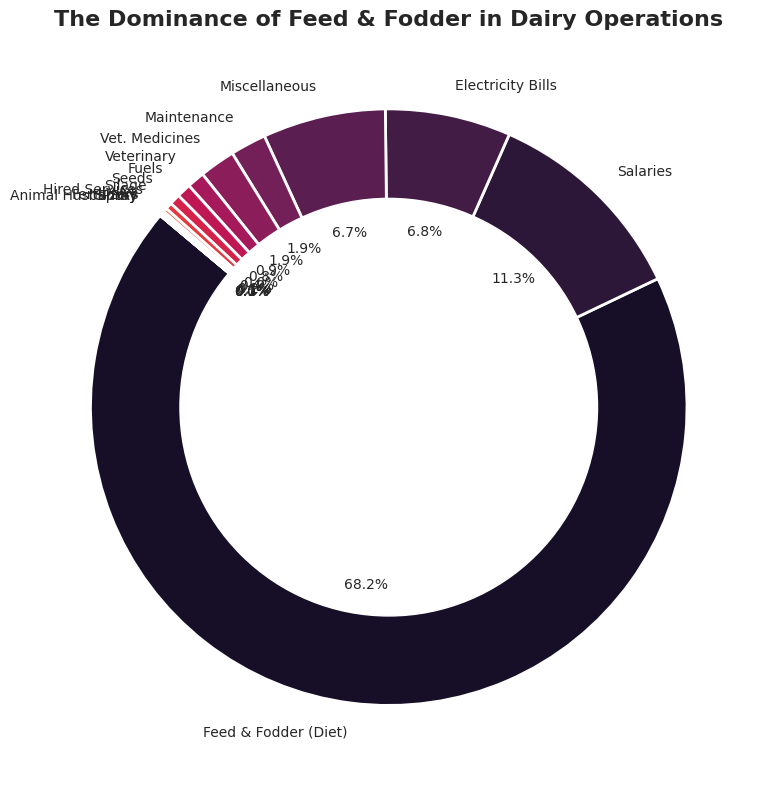

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. OVERALL FINANCIAL SUMMARY TABLE
# ==========================================
total_months = len(monthly_finance)
avg_monthly_income = monthly_finance['total_income'].mean()
avg_monthly_expense = monthly_finance['total_expense'].mean()
avg_monthly_profit = monthly_finance['net_profit'].mean()

# Create a clean, professional summary table
summary_data = {
    'Financial Metric': [
        'Total Months Analyzed', 
        'Average Monthly Income', 
        'Average Monthly Expense', 
        'Average Monthly Net Profit/Loss'
    ],
    'Value': [
        f"{total_months} Months",
        f"{avg_monthly_income:,.2f} PKR",
        f"{avg_monthly_expense:,.2f} PKR",
        f"{avg_monthly_profit:,.2f} PKR"
    ]
}
financial_summary_df = pd.DataFrame(summary_data)

print("📊 OVERALL FINANCIAL SUMMARY (2019 - 2025)")
display(financial_summary_df)
print("-" * 60)

# ==========================================
# 2. COMBINING FEED & FODDER
# ==========================================
# Create a new column where 'Feed' and 'Fodder' are merged into one category
df_expenses['category_grouped'] = df_expenses['category'].replace({
    'Feed': 'Feed & Fodder (Diet)', 
    'Fodder': 'Feed & Fodder (Diet)'
})

# Recalculate the expenses with the new grouped categories
category_expenses_grouped = df_expenses.groupby('category_grouped')['amount'].sum().reset_index()
category_expenses_grouped = category_expenses_grouped.sort_values(by='amount', ascending=False)

# Add a percentage column to show how much each category consumes of the total budget
total_expense_all = category_expenses_grouped['amount'].sum()
category_expenses_grouped['Budget %'] = (category_expenses_grouped['amount'] / total_expense_all * 100).round(1)

print("\n📈 EXPENSE BREAKDOWN (COMBINED DIET)")
display(category_expenses_grouped.head(7))

# ==========================================
# 3. VISUALIZING THE DOMINANCE OF ANIMAL DIET
# ==========================================
plt.figure(figsize=(12, 8))

# Using a distinct color palette to make the massive 'Diet' chunk stand out
colors = sns.color_palette("rocket", len(category_expenses_grouped))

plt.pie(category_expenses_grouped['amount'], labels=category_expenses_grouped['category_grouped'], 
        autopct='%1.1f%%', startangle=140, colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# Donut chart style
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('The Dominance of Feed & Fodder in Dairy Operations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. The Executive Summary: 77-Month Comprehensive Business Performance

### The Complete 77-Month Picture & Asset Equity
To truly evaluate the success of Desi Farm over its 77-month lifecycle (July 2019 to October 2025), we must rely strictly on the recorded data. We calculate every single rupee of operational and capital cash flows directly from the ledgers. 

However, cash alone doesn't show the full picture. A significant portion of the purchased animals (worth approximately **5,000,000 PKR**) are still actively present on the farm. This standing inventory is a highly liquid asset and must be added to our Total Revenue to reveal the actual **Ultimate Grand Net Profit**.

### Key Performance Indicators (KPIs)
1. **Total Revenue & Assets:** Data-driven milk sales, actual animal sales from the ledger, PLUS the 5.0 Million PKR current market value of standing animals.
2. **Total Expenses:** All operational costs and exact animal purchase costs from the ledger.
3. **Overall Profitability & Margin:** The true net income and the Profit Margin (%).

🌟 DESI FARM: 77-MONTH AUDITED MASTER STATEMENT 🌟


,Audited Financial Metrics (77 Months),Amount / Percentage
0,--- 🟢 REVENUE & ASSETS ---,
1,1. Operational Revenue (Milk Sales),"38,531,026 PKR"
2,2. Capital Investment (Animal Purchase Cost),"- 9,443,500 PKR"
3,3. Capital Revenue (Animal Sales Revenue),"14,994,400 PKR"
4,4. Standing Livestock Inventory (Active Assets...,"5,000,000 PKR"
5,⭐ GRAND TOTAL REVENUE & ASSETS,"58,525,426 PKR"
6,--- 🔴 EXPENSES ---,
7,"5. Total Operational Expenses (Feed, Fodder, B...","47,574,860 PKR"
8,--- 🔵 AUDITED PROFITABILITY ---,
9,6. Operational Profit / Loss (Milk vs. Feed),"-9,043,834 PKR"


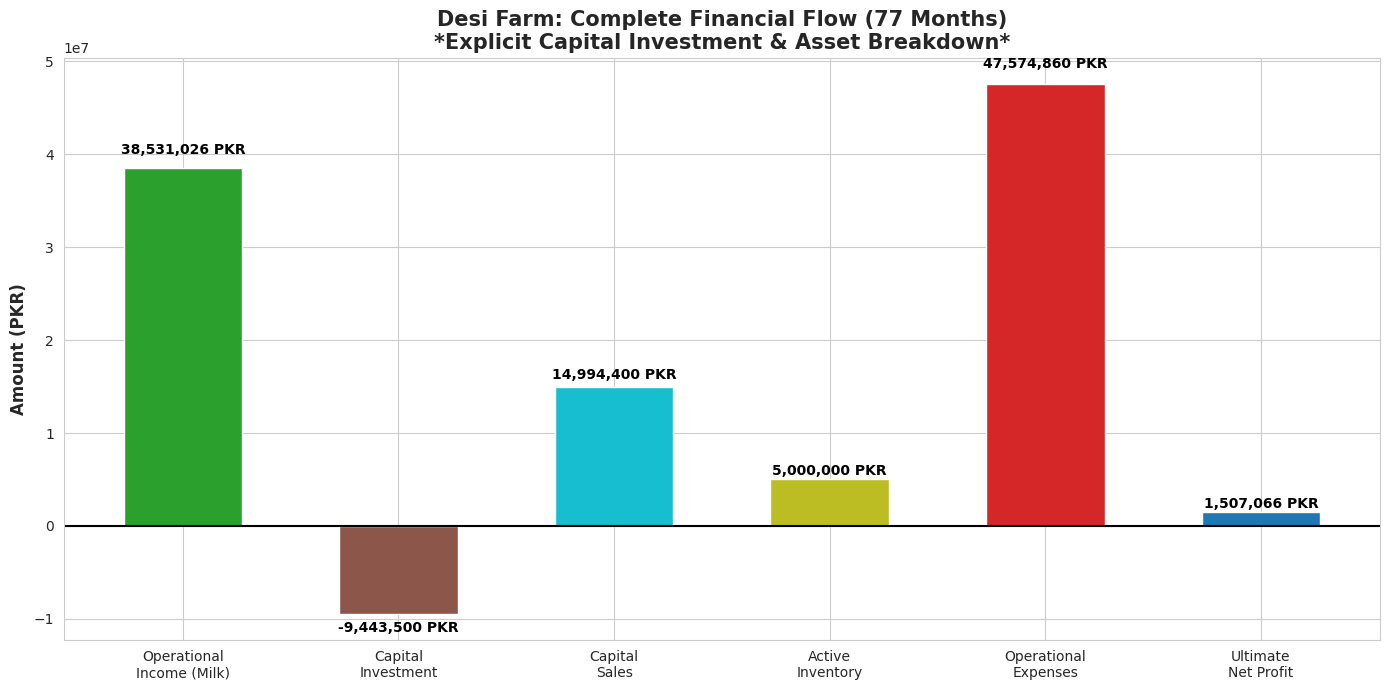

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. DETAILED FINANCIAL LEDGER VALUES
# ==========================================
# Operational (Milk Income vs Daily Expenses)
op_income = monthly_finance['total_income'].sum()
op_expense = monthly_finance['total_expense'].sum()
op_profit = monthly_finance['net_profit'].sum()

# Capital & Livestock Ledger (Strictly from audited records)
cap_investment = 9443500      # Total Capital Invested in Buying Animals
cap_sales = 14994400          # Total Capital Revenue from Selling Animals
trading_profit = 5550900        # Net Trading Profit (Sales minus Investment)
inventory_value = 5000000       # Standing Livestock Inventory on Farm

# Total Capital Value Creation
total_capital_profit = trading_profit + inventory_value

# Ultimate Enterprise Totals
total_revenue = op_income + cap_sales + inventory_value
grand_net_profit = op_profit + total_capital_profit

# Averages & Efficiency (77 Months)
total_months = len(monthly_finance)
avg_monthly_revenue = total_revenue / total_months
avg_monthly_profit = grand_net_profit / total_months
profit_margin = (grand_net_profit / total_revenue) * 100

# ==========================================
# 2. COMPREHENSIVE AUDITED SUMMARY TABLE
# ==========================================
summary_data = {
    f'Audited Financial Metrics ({total_months} Months)': [
        '--- 🟢 REVENUE & ASSETS ---',
        '1. Operational Revenue (Milk Sales)',
        '2. Capital Investment (Animal Purchase Cost)',
        '3. Capital Revenue (Animal Sales Revenue)',
        '4. Standing Livestock Inventory (Active Assets on Farm)',
        '⭐ GRAND TOTAL REVENUE & ASSETS',
        '--- 🔴 EXPENSES ---',
        '5. Total Operational Expenses (Feed, Fodder, Bills)',
        '--- 🔵 AUDITED PROFITABILITY ---',
        '6. Operational Profit / Loss (Milk vs. Feed)',
        '7. Capital Trading Profit (Sales minus Purchase Cost)',
        '8. Total Capital Profit (Trading Profit + Inventory)',
        '🏆 ULTIMATE GRAND NET PROFIT',
        '--- 📊 MONTHLY AVERAGES & EFFICIENCY ---',
        'Average Monthly Revenue',
        'Average Monthly Net Profit',
        'Overall Profit Margin (%)'
    ],
    'Amount / Percentage': [
        '',
        f"{op_income:,.0f} PKR",
        f"- {cap_investment:,.0f} PKR",
        f"{cap_sales:,.0f} PKR",
        f"{inventory_value:,.0f} PKR",
        f"{total_revenue:,.0f} PKR",
        '',
        f"{op_expense:,.0f} PKR",
        '',
        f"{op_profit:,.0f} PKR",
        f"{trading_profit:,.0f} PKR",
        f"{total_capital_profit:,.0f} PKR",
        f"{grand_net_profit:,.0f} PKR",
        '',
        f"{avg_monthly_revenue:,.0f} PKR",
        f"{avg_monthly_profit:,.0f} PKR",
        f"{profit_margin:.2f} %"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(f"🌟 DESI FARM: 77-MONTH AUDITED MASTER STATEMENT 🌟")
display(summary_df)

# ==========================================
# 3. ELABORATIVE VISUALIZATION (Full Breakdown)
# ==========================================
plt.figure(figsize=(14, 7))

# Including Capital Investment explicitly in the chart to show the complete money flow
categories = [
    'Operational\nIncome (Milk)', 
    'Capital\nInvestment', 
    'Capital\nSales', 
    'Active\nInventory', 
    'Operational\nExpenses', 
    'Ultimate\nNet Profit'
]
values = [op_income, -cap_investment, cap_sales, inventory_value, op_expense, grand_net_profit]
colors = ['#2ca02c', '#8c564b', '#17becf', '#bcbd22', '#d62728', '#1f77b4']

bars = plt.bar(categories, values, color=colors, width=0.55)

plt.axhline(0, color='black', linewidth=1.5)
plt.title(f'Desi Farm: Complete Financial Flow ({total_months} Months)\n*Explicit Capital Investment & Asset Breakdown*', fontsize=15, fontweight='bold')
plt.ylabel('Amount (PKR)', fontsize=12, fontweight='bold')

# Print values on top/bottom of bars clearly
for bar in bars:
    yval = bar.get_height()
    y_offset = yval * 0.03 if yval > 0 else yval * 0.08
    plt.text(bar.get_x() + bar.get_width()/2, yval + y_offset, f"{yval:,.0f} PKR", 
             ha='center', va='bottom' if yval > 0 else 'top', fontweight='bold', fontsize=10, color='black')

plt.tight_layout()
plt.show()